In [5]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# このnotebook用に変更する
# =========================
FIG_DIR_NAME = "fig4_B"  # fig4_B, fig5, fig7, fig8_B に変更

# =========================
# project root を探す
# =========================
def find_project_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "rumor_model.py").exists() and (p / "fig_experiments.py").exists():
            return p
    raise FileNotFoundError("rumor_model.py と fig_experiments.py が見つかりません")

PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / FIG_DIR_NAME
FIG_DIR.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from rumor_model import (
    ADVISOR,
    LIAR,
    LIKE_TFT,
    CONDITIONAL_ADVISOR,
)

from fig_experiments import (
    run_checkpoint_experiment,
    plot_result_scatter,
    summarize_trials,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIG_DIR:", FIG_DIR)

PROJECT_ROOT: c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム
FIG_DIR: c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム\fig4_B


In [7]:
fig4B_summary, fig4B_trials = run_checkpoint_experiment(
    fig_name="fig4_B",
    target_strategy=ADVISOR,
    opponent_strategy=LIAR,
    T_values=list(range(100, 1001, 100)),
    r_values=list(range(0, 11)),
    freq_values=[0.9],
    g=5,
    repeat=100,
    max_generations=500,
    result_dir=FIG_DIR,
    n_jobs=6,
    chunk_size=12,
    base_seed=410000,
)

checkpoint loaded: c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム\fig4_B\trials_checkpoint.csv
figure         : fig4_B
result_dir     : c:\Users\yushi\Documents\図齋ゼミ\研究\進化するシステム\fig4_B
all tasks      : 11000
done           : 108
remaining      : 10892
repeat         : 100
max_generations: 500
n_jobs         : 6
chunk_size     : 12
fig4_B: 11000 / 11000 finished (201.2 min)


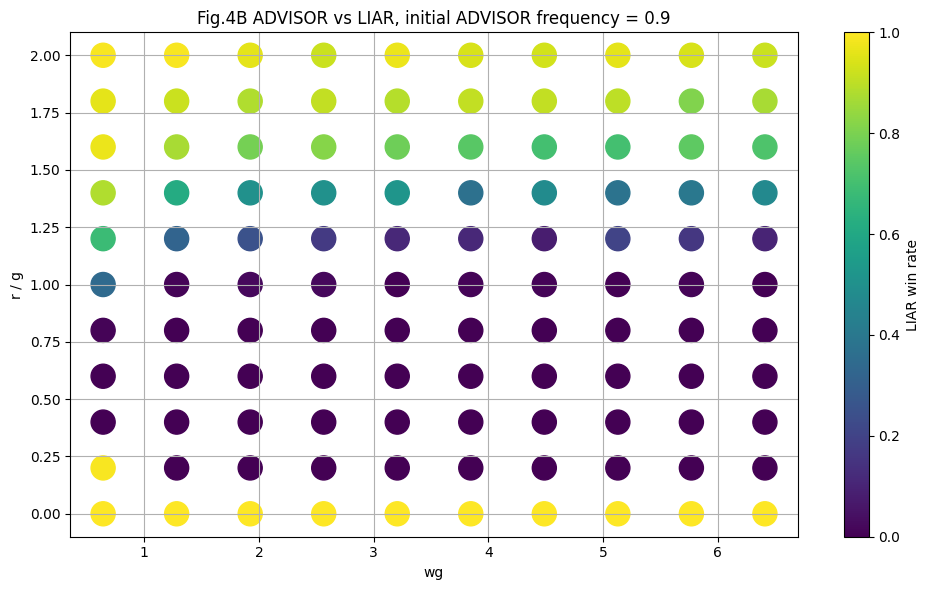

In [8]:
plot_result_scatter(
    df_summary=fig4B_summary,
    x_col="wg",
    y_col="r_over_g",
    color_col="opponent_win_rate",
    title="Fig.4B ADVISOR vs LIAR, initial ADVISOR frequency = 0.9",
    save_path=FIG_DIR / "fig4_B_scatter.png",
    xlabel="wg",
    ylabel="r / g",
    color_label="LIAR win rate",
)